# Abhishek Kothari
# Homework 5B

In [2]:
from sklearn.datasets import fetch_20newsgroups
newsgroups_data = fetch_20newsgroups(subset='all', remove=('headers', 'footers', 'quotes'), download_if_missing=True)

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import random
from math import exp, sqrt, pi


### Question 1

In [46]:
# 1. Uniform Sampling using Inverse Transform Sampling
def sample_uniform(min_val, max_val, sample_size):
    u = np.random.rand(sample_size)  # Uniform [0, 1]
    return min_val + (max_val - min_val) * u  # Inverse transform

# 2. Gaussian Sampling using Rejection Sampling
def normal_pdf(x, mu=0, sigma=1):
    """Normal distribution PDF."""
    return (1 / (sqrt(2 * pi) * sigma)) * exp(-0.5 * ((x - mu) / sigma) ** 2)

def sample_gaussian(mu, sigma, sample_size):
    """Sample from Gaussian using Rejection Sampling."""
    samples = []
    c = 1.1  # Safety factor, > max PDF value
    
    # Use proposal distribution: Uniform in range (mu-4σ, mu+4σ)
    while len(samples) < sample_size:
        x = mu - 4*sigma + 8*sigma * np.random.rand()  # Sample x from proposal
        y = np.random.rand() * normal_pdf(mu, mu, sigma)  # Sample y between 0 and peak of PDF
        if y <= normal_pdf(x, mu, sigma):
            samples.append(x)
    
    return np.array(samples)

In [10]:
def sample_2d_gaussian(mu, sigma, sample_size):
    # Cholesky decomposition to generate correlated Gaussian
    L = np.linalg.cholesky(sigma)
    z = np.random.randn(sample_size, 2)
    samples = z @ L.T + mu
    return samples

In [20]:
def stevens_sample_without_replacement(population, probs, N):
    M = len(population)
    if N > M:
        raise ValueError("Sample size N cannot be greater than population size M")

    selected_indices = []
    remaining_probs = np.array(probs, copy=True)
    remaining_probs /= remaining_probs.sum()

    for _ in range(N):
        r = np.random.rand()
        cum_sum = 0
        for i, p in enumerate(remaining_probs):
            cum_sum += p
            if r <= cum_sum:
                selected_indices.append(i)
                remaining_probs[i] = 0  # Remove selected item
                remaining_probs /= remaining_probs.sum()  # Renormalize
                break

    return selected_indices

In [16]:
labels = newsgroups_data.target
label_names = newsgroups_data.target_names

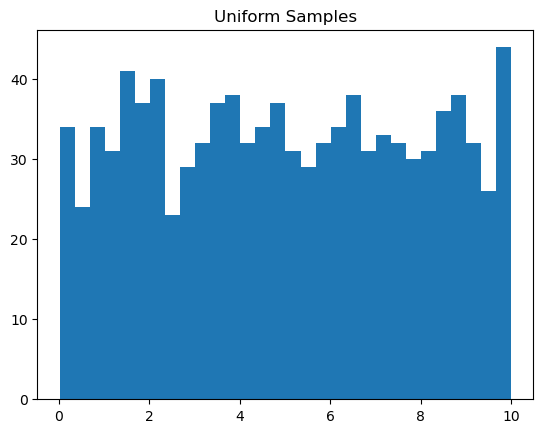

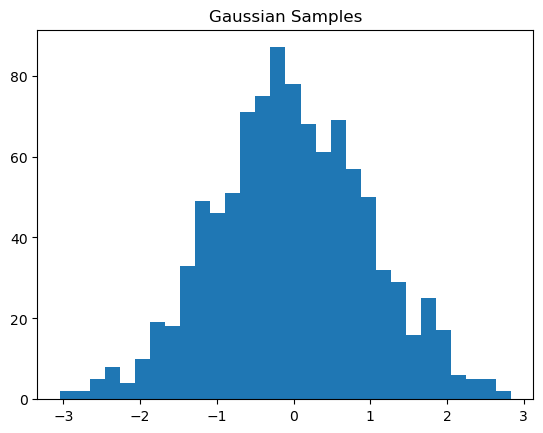

In [52]:
### A)
# Uniform Samples
samples_uniform = sample_uniform(0, 10, 1000)
plt.hist(samples_uniform, bins=30)
plt.title("Uniform Samples")
plt.show()

# Gaussian Samples
samples_gaussian = sample_gaussian(0, 1, 1000)
plt.hist(samples_gaussian, bins=30)
plt.title("Gaussian Samples")
plt.show()

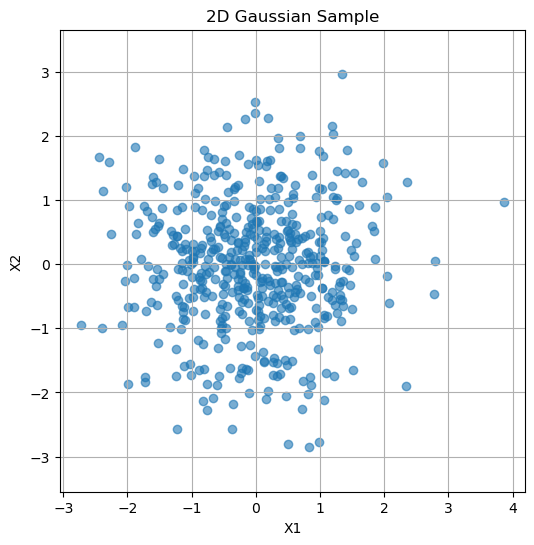

In [34]:
### B)
mu = [0, 0]
sigma = [[1, 0], [0, 1]]
samples_2d = sample_2d_gaussian(mu, sigma, sample_size=500)

# Plot
plt.figure(figsize=(6, 6))
plt.scatter(samples_2d[:, 0], samples_2d[:, 1], alpha=0.6)
plt.title("2D Gaussian Sample")
plt.xlabel("X1")
plt.ylabel("X2")
plt.grid(True)
plt.axis("equal")
plt.show()

In [36]:
### C)
def stevens_sampling(population, probabilities, sample_size):
    assert len(population) == len(probabilities), "Population and probabilities must be same length."
    assert np.isclose(sum(probabilities), 1), "Probabilities must sum to 1."
    assert sample_size <= len(population), "Sample size must be less than or equal to population size."
    
    scores = []
    for item, prob in zip(population, probabilities):
        u = np.random.rand()
        score = u ** (1 / prob)
        scores.append((score, item))

    # Select top-N items based on score
    scores.sort(reverse=True)  # higher score = higher chance of selection
    sampled_items = [item for (_, item) in scores[:sample_size]]
    
    return sampled_items

In [38]:
# Sample first 300 documents
docs_subset = newsgroups_data['data'][:300]
targets_subset = newsgroups_data['target'][:300]
categories = newsgroups_data['target_names']

In [42]:
counter = Counter(targets_subset)
total = sum(counter.values())
class_probs = [counter[i]/total for i in range(len(categories))]

# Create population: just use indexes or (doc, label) pairs
population = list(range(len(docs_subset)))

# Map each document index to its class probability
doc_probs = [class_probs[targets_subset[i]] for i in range(len(docs_subset))]

# ✅ Normalize to ensure sum = 1
total_prob = sum(doc_probs)
doc_probs = [p / total_prob for p in doc_probs]

# Run Steven's Sampling (after normalization)
sampled_doc_indices = stevens_sampling(population, doc_probs, sample_size=20)

# View results
print("Sampled Indices:", sampled_doc_indices)
print("\nSampled Labels:")
for i in sampled_doc_indices:
    print(f"Doc #{i} -> Category: {categories[targets_subset[i]]}")

Sampled Indices: [79, 131, 27, 145, 288, 260, 66, 259, 253, 295, 159, 199, 99, 128, 170, 251, 133, 161, 216, 113]

Sampled Labels:
Doc #79 -> Category: rec.sport.hockey
Doc #131 -> Category: soc.religion.christian
Doc #27 -> Category: comp.graphics
Doc #145 -> Category: sci.crypt
Doc #288 -> Category: comp.sys.mac.hardware
Doc #260 -> Category: comp.sys.ibm.pc.hardware
Doc #66 -> Category: rec.sport.hockey
Doc #259 -> Category: comp.graphics
Doc #253 -> Category: comp.sys.ibm.pc.hardware
Doc #295 -> Category: comp.windows.x
Doc #159 -> Category: comp.sys.mac.hardware
Doc #199 -> Category: comp.graphics
Doc #99 -> Category: comp.windows.x
Doc #128 -> Category: sci.electronics
Doc #170 -> Category: comp.sys.mac.hardware
Doc #251 -> Category: sci.electronics
Doc #133 -> Category: rec.sport.hockey
Doc #161 -> Category: comp.sys.ibm.pc.hardware
Doc #216 -> Category: comp.os.ms-windows.misc
Doc #113 -> Category: comp.windows.x


### Question 2

In [55]:
def gibbs_sampler_2d(mu, cov, num_samples=1000, burn_in=100):
    samples = []
    
    # Initial values
    x1, x2 = 0.0, 0.0

    # Extract parameters
    mu1, mu2 = mu
    sigma11, sigma12 = cov[0]
    sigma21, sigma22 = cov[1]

    # Precompute conditional variances
    sigma1_given_2 = np.sqrt(sigma11 - sigma12 * sigma21 / sigma22)
    sigma2_given_1 = np.sqrt(sigma22 - sigma12 * sigma21 / sigma11)

    for i in range(num_samples + burn_in):
        # Sample x1 | x2
        mu1_given_2 = mu1 + sigma12 / sigma22 * (x2 - mu2)
        x1 = np.random.normal(mu1_given_2, sigma1_given_2)

        # Sample x2 | x1
        mu2_given_1 = mu2 + sigma21 / sigma11 * (x1 - mu1)
        x2 = np.random.normal(mu2_given_1, sigma2_given_1)

        if i >= burn_in:
            samples.append([x1, x2])

    return np.array(samples)

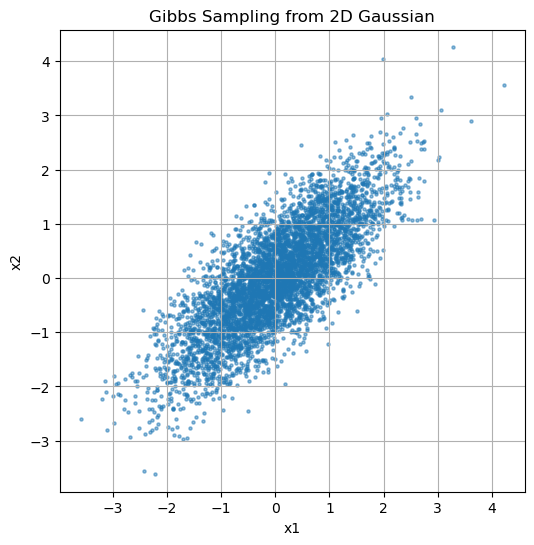

In [57]:
# Mean and covariance for 2D Gaussian
mu = [0, 0]
cov = [[1.0, 0.8],
       [0.8, 1.0]]

# Run Gibbs Sampling
samples = gibbs_sampler_2d(mu, cov, num_samples=5000)

# Plot
plt.figure(figsize=(6, 6))
plt.scatter(samples[:, 0], samples[:, 1], s=5, alpha=0.5)
plt.title("Gibbs Sampling from 2D Gaussian")
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid(True)
plt.axis("equal")
plt.show()

### Problem 3

In [60]:
import numpy as np
import re
from collections import defaultdict, Counter
from sklearn.feature_extraction.text import CountVectorizer
import random

In [80]:
# Parameters
K = 20          # Number of topics
D = 10000        # Number of documents
DLMAX = 100    # Max doc length (truncate to this)
TOP_WORDS = 1000  # Vocabulary size


In [82]:
# Subset the data
docs_raw = newsgroups_data.data[:D]

# Tokenize and build vocabulary
vectorizer = CountVectorizer(max_features=TOP_WORDS, stop_words='english')
X = vectorizer.fit_transform(docs_raw).toarray()
vocab = vectorizer.get_feature_names_out()
word2id = {word: idx for idx, word in enumerate(vocab)}
id2word = {idx: word for word, idx in word2id.items()}


In [84]:
# Convert to DOCS matrix: D x DLMAX with word indices
DOCS = np.zeros((D, DLMAX), dtype=int)
for d, doc_vec in enumerate(X):
    words = np.repeat(np.arange(TOP_WORDS), doc_vec)
    random.shuffle(words)
    DOCS[d, :min(DLMAX, len(words))] = words[:DLMAX]

W = TOP_WORDS

In [86]:
alpha = np.ones(K) * 5
beta = np.ones(W) * 2

A = np.tile(alpha, (D, 1))  # D x K
B = np.tile(beta, (K, 1))   # K x W
BSUM = B.sum(axis=1)        # K x 1

Z = np.zeros((D, DLMAX), dtype=int)  # Topic assignment

In [88]:
# Gubbs sampling loop
def sample_topic(dist):
    dist = dist / np.sum(dist)
    return np.random.choice(np.arange(K), p=dist)

T = 100  # Number of iterations

for it in range(T):
    for d in range(D):
        for i in range(DLMAX):
            w = DOCS[d, i]
            zi = Z[d, i]

            # Remove old topic
            if zi > 0:
                A[d, zi] -= 1
                B[zi, w] -= 1
                BSUM[zi] -= 1

            # Compute new topic distribution
            prob = A[d, :] * (B[:, w] / BSUM)
            new_zi = sample_topic(prob)

            # Update counts
            Z[d, i] = new_zi
            A[d, new_zi] += 1
            B[new_zi, w] += 1
            BSUM[new_zi] += 1

    if it % 10 == 0:
        print(f"Iteration {it} completed.")

Iteration 0 completed.
Iteration 10 completed.
Iteration 20 completed.
Iteration 30 completed.
Iteration 40 completed.
Iteration 50 completed.
Iteration 60 completed.
Iteration 70 completed.
Iteration 80 completed.
Iteration 90 completed.


In [92]:
def print_top_words(B, vocab, top_n=10):
    for k in range(K):
        top_indices = np.argsort(B[k, :])[::-1][:top_n]
        top_words = [(vocab[i], B[k, i]) for i in top_indices]
        print(f"\nTopic {k}:")
        for word, prob in top_words:
            print(f"{word}: {prob:.2f}")

print_top_words(B, vocab, top_n=20)


Topic 0:
00: 64709358.00
like: 268230.00
don: 267946.00
just: 256180.00
know: 236456.00
people: 231033.00
think: 202821.00
time: 184707.00
use: 170793.00
does: 164370.00
good: 158892.00
new: 144043.00
way: 131822.00
make: 129826.00
ve: 124628.00
say: 113710.00
did: 113516.00
god: 112355.00
used: 112148.00
problem: 109100.00

Topic 1:
period: 123.00
pts: 75.00
van: 75.00
11: 75.00
pp: 70.00
la: 68.00
buf: 66.00
12: 63.00
19: 53.00
18: 51.00
55: 49.00
17: 48.00
10: 48.00
34: 47.00
14: 42.00
16: 41.00
38: 34.00
37: 32.00
35: 28.00
33: 28.00

Topic 2:
29: 12.00
fonts: 10.00
earth: 9.00
42: 8.00
graphics: 8.00
13: 8.00
70: 7.00
27: 7.00
34: 7.00
22: 7.00
real: 7.00
28: 7.00
mb: 7.00
65: 6.00
91: 6.00
31: 6.00
interface: 6.00
55: 6.00
anonymous: 6.00
sort: 6.00

Topic 3:
27: 11.00
april: 11.00
95: 9.00
33: 9.00
archive: 8.00
hit: 8.00
50: 8.00
11: 8.00
24: 8.00
bits: 7.00
sci: 7.00
page: 7.00
ah: 7.00
days: 7.00
koresh: 7.00
x11: 7.00
91: 7.00
dave: 7.00
info: 6.00
32: 6.00

Topic 4:
xterm:

In [76]:
!pip install WordCloud

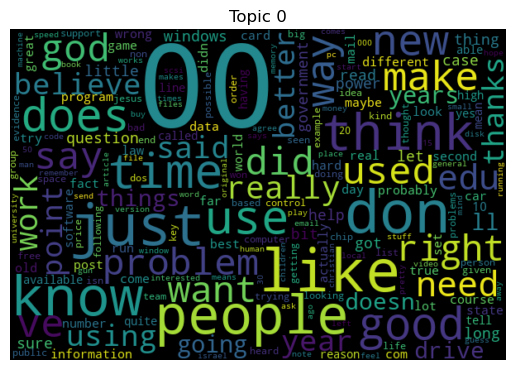

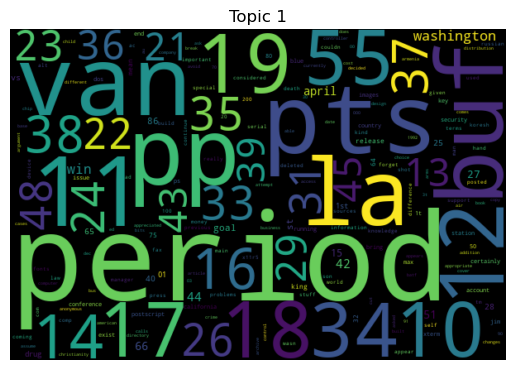

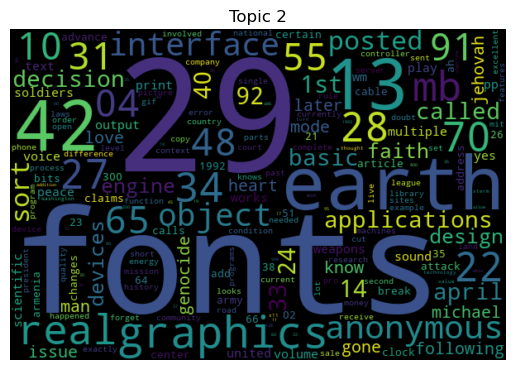

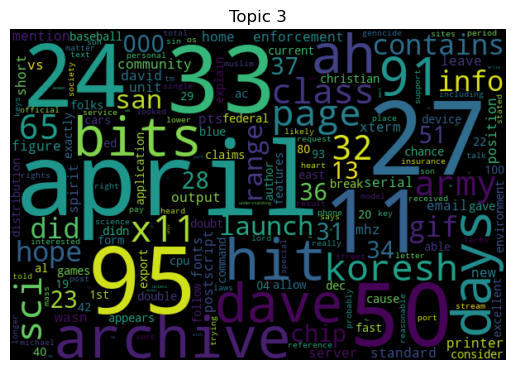

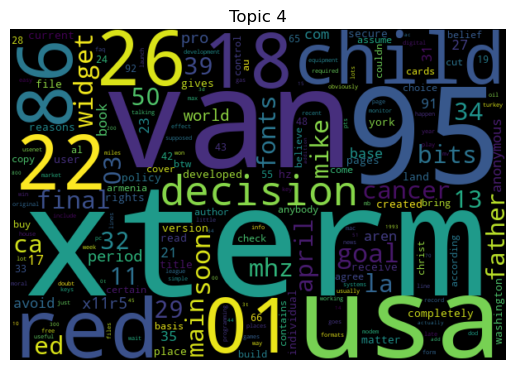

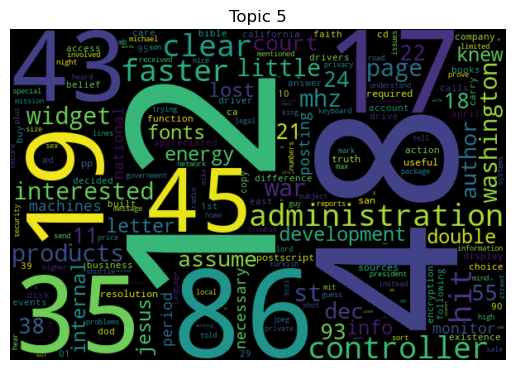

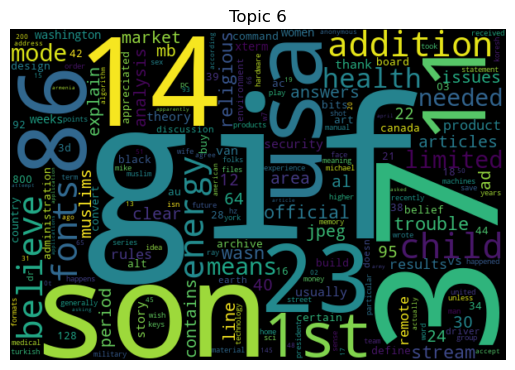

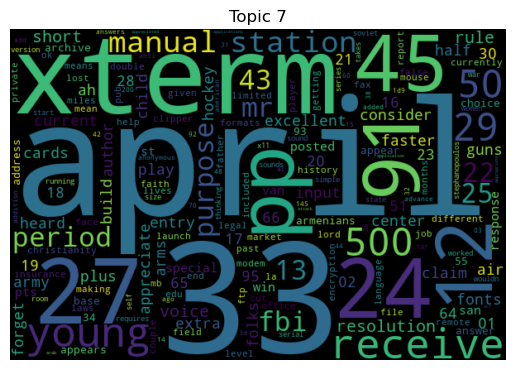

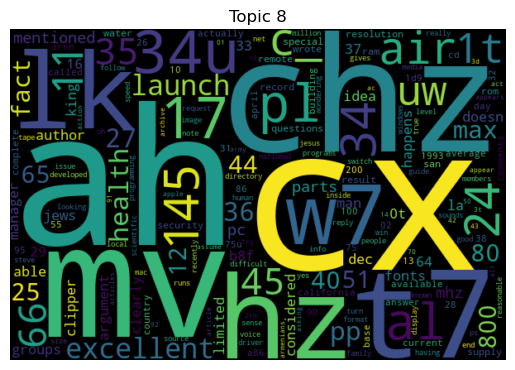

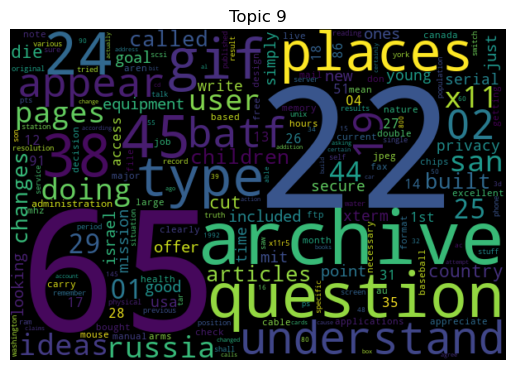

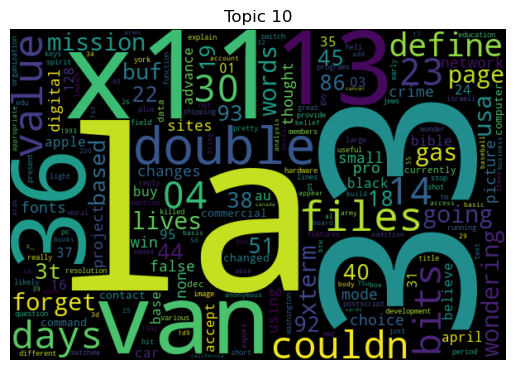

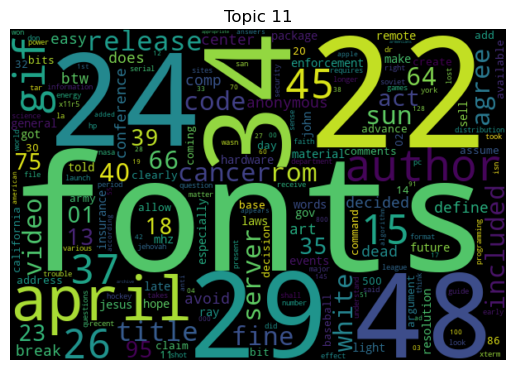

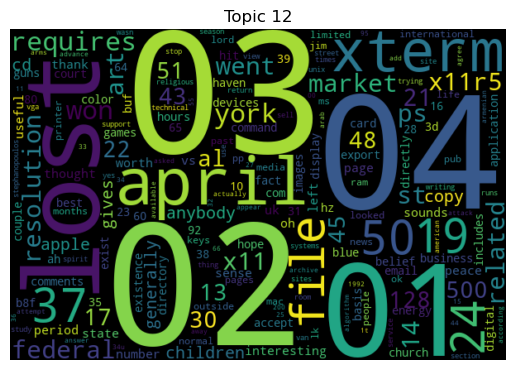

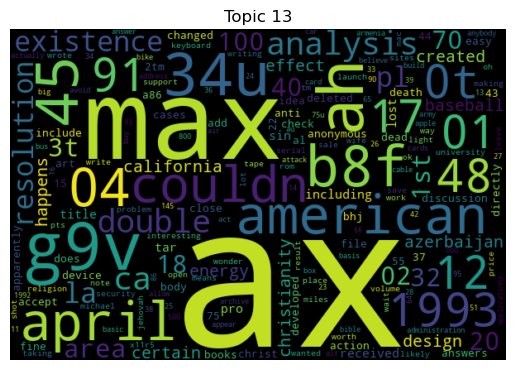

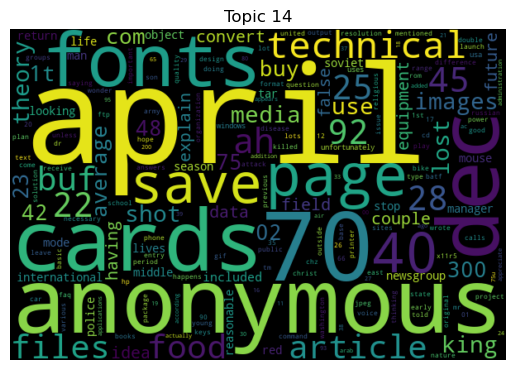

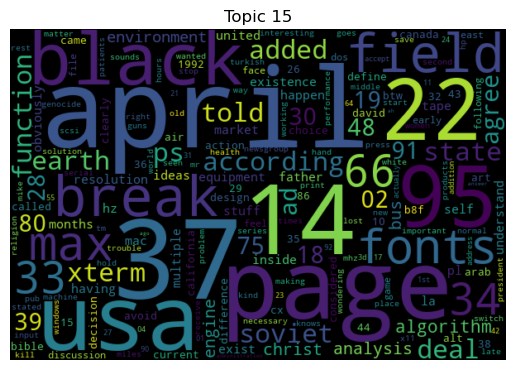

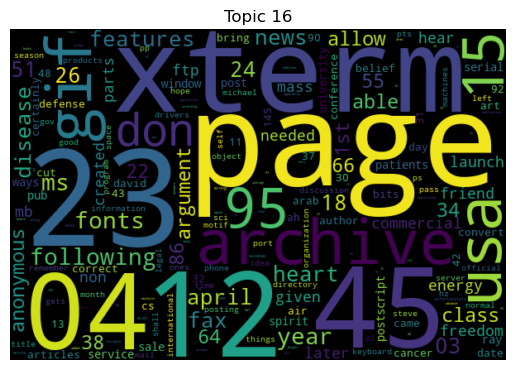

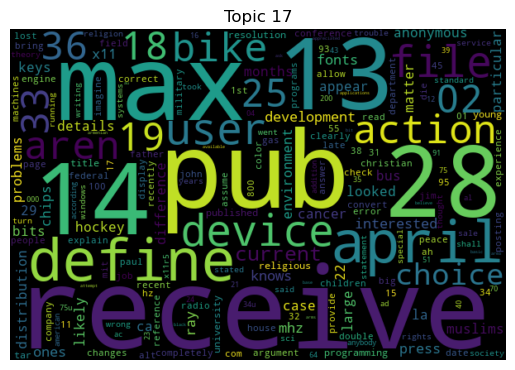

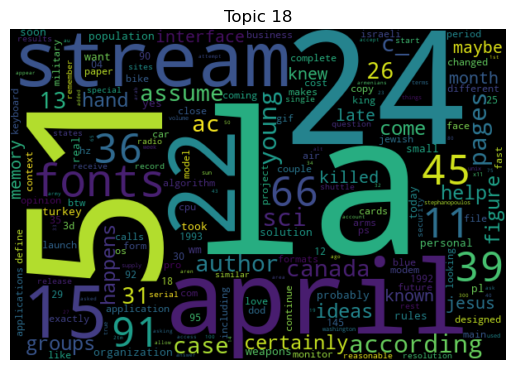

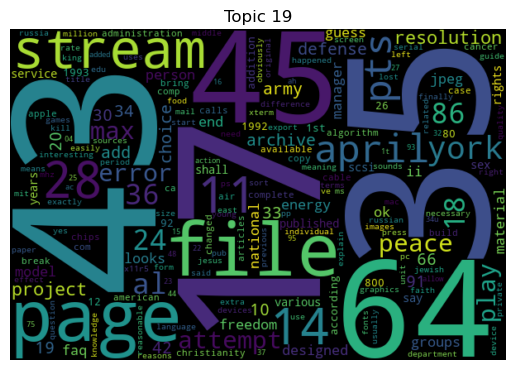

In [94]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

for k in range(K):
    topic_words = {vocab[w]: B[k, w] for w in range(W)}
    wordcloud = WordCloud(width=600, height=400).generate_from_frequencies(topic_words)
    plt.figure()
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Topic {k}")
    plt.show()